# **IMDb Movie Review Sentiment Analysis**

## 1. Problem Statement

Movie reviews contain valuable information about viewers' opinions and experiences. Automatically identifying whether a review expresses a positive or negative sentiment can be treated as a binary text classification problem.

The objective of this project is to develop a machine learning model that analyzes the textual content of IMDb movie reviews and predicts their sentiment as either positive or negative.

The project uses traditional text processing and machine learning techniques rather than deep learning. Review text is converted into numerical features using TF-IDF vectorization, and a Linear Support Vector Machine is used for sentiment classification.

## 2. Objective

The main objective of this project is to develop a classical machine learning model that can automatically classify IMDb movie reviews as positive or negative based on their textual content.

The project aims to:

- Load and analyze the IMDb movie review dataset.
- Perform appropriate text preprocessing.
- Convert review text into numerical features using TF-IDF vectorization.
- Train a Linear Support Vector Machine for binary sentiment classification.
- Evaluate the model using appropriate classification metrics.
- Save the complete TF-IDF and Linear SVM pipeline as a deployment-ready model artifact.
- Integrate the trained model into a Streamlit application for interactive movie review sentiment analysis.

## 3. Dataset Overview

The IMDb Large Movie Review Dataset is a benchmark dataset for binary sentiment classification of movie reviews.

The dataset contains 50,000 labeled movie reviews collected from IMDb. It is divided into 25,000 training reviews and 25,000 test reviews, with an equal number of positive and negative reviews in each split.

The reviews are strongly polarized. Positive reviews have ratings of 7 or higher out of 10, while negative reviews have ratings of 4 or lower. Neutral reviews are excluded from the dataset.

Each review consists of raw text, with the corresponding sentiment label indicating whether the review is positive or negative.

### Dataset Characteristics

- Total labeled reviews: 50,000
- Training reviews: 25,000
- Test reviews: 25,000
- Classes: Positive and Negative
- Task: Binary text classification
- Input: Movie review text
- Target: Sentiment label

The dataset also contains 50,000 additional unlabeled reviews. These unlabeled reviews will not be used in this project because the objective is to build a supervised classical machine learning model using the labeled training and test data.

## 4. Load the Dataset


In [1]:
import os
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/IMDB Movie Review/aclImdb_v1.tar.gz"
print(os.path.exists(dataset_path))

True


In [4]:
print(os.listdir(dataset_path))

['test', 'README', 'imdb.vocab', 'imdbEr.txt', 'train']


In [5]:
print("Train folders:", os.listdir(
    os.path.join(dataset_path, "train")
))

print("Test folders:", os.listdir(
    os.path.join(dataset_path, "test")
))

Train folders: ['unsup', 'urls_neg.txt', 'pos', 'unsupBow.feat', 'labeledBow.feat', 'urls_unsup.txt', 'urls_pos.txt', 'neg']
Test folders: ['urls_neg.txt', 'pos', 'labeledBow.feat', 'urls_pos.txt', 'neg']


In [6]:
import pandas as pd

def load_reviews(data_path):
    reviews = []
    labels = []

    for label, label_value in [("neg", 0), ("pos", 1)]:
        label_path = os.path.join(
            data_path,
            label
        )

        for file_name in os.listdir(label_path):
            if file_name.endswith(".txt"):
                file_path = os.path.join(
                    label_path,
                    file_name
                )

                with open(
                    file_path,
                    "r",
                    encoding="utf-8"
                ) as file:
                    review = file.read()

                reviews.append(review)
                labels.append(label_value)

    return pd.DataFrame({
        "review": reviews,
        "sentiment": labels
    })

In [7]:
train_data = load_reviews(
    os.path.join(dataset_path, "train")
)

test_data = load_reviews(
    os.path.join(dataset_path, "test")
)

print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Training data shape: (25000, 2)
Test data shape: (25000, 2)


## 5. Dataset Exploration

The training dataset contains 25,000 labeled movie reviews, with 12,500 negative reviews and 12,500 positive reviews.

The classes are perfectly balanced, so no class-balancing technique is required for the sentiment classification model.

The review text will be used as the input feature, while the sentiment label will be used as the target variable.

In [8]:
train_data.head()

,review,sentiment
0,"This is the weakest of the series, not much of...",0
1,What an insult to Olivia D'Abo who plays the f...,0
2,I am writing this review having watched it sev...,0
3,Nowhere near the original. It's quite accurate...,0
4,This is a very bad western mainly because it i...,0


In [10]:
print(train_data["sentiment"].value_counts())

sentiment
0    12500
1    12500
Name: count, dtype: int64


## 6. Text Preprocessing and Vectorization

The raw IMDb reviews are converted into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization.

The vectorizer converts the review text into a sparse document-term matrix. Reviews are converted to lowercase, English stop words are removed, and both unigrams and bigrams are considered to capture individual words as well as short sentiment-related phrases.

The TF-IDF vectorizer will be included directly in the final machine learning pipeline so that the same text transformation is automatically applied during model deployment.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [12]:
train_x = tfidf_vectorizer.fit_transform(
    train_data["review"]
)

test_x = tfidf_vectorizer.transform(
    test_data["review"]
)

train_y = train_data["sentiment"].values
test_y = test_data["sentiment"].values

In [13]:
print("Training feature matrix shape:", train_x.shape)
print("Test feature matrix shape:", test_x.shape)

Training feature matrix shape: (25000, 311967)
Test feature matrix shape: (25000, 311967)


In [14]:
print("Training matrix type:", type(train_x))
print("Test matrix type:", type(test_x))

Training matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Test matrix type: <class 'scipy.sparse._csr.csr_matrix'>


## 7. Linear SVM

A Linear Support Vector Machine (Linear SVM) is used to classify the IMDb movie reviews into positive and negative sentiment classes.

Linear SVM is well suited for text classification because TF-IDF produces a high-dimensional sparse feature matrix, and linear classifiers can efficiently operate on this type of representation.

The model learns a decision boundary that separates positive and negative reviews based on their TF-IDF features.

The regularization parameter `C` is set to `1.0`. The training dataset is already perfectly balanced, so class weighting is not required.


In [15]:
from sklearn.svm import LinearSVC

model = LinearSVC(
    C=1.0,
    random_state=42
)

model.fit(
    train_x,
    train_y
)

LinearSVC(random_state=42)

## 8. Model Evaluation

The trained Linear SVM is evaluated on the unseen IMDb test set.

The test reviews were not used during TF-IDF fitting or model training. The evaluation therefore measures how well the final model generalizes to previously unseen movie reviews.

Accuracy, precision, recall, and F1-score are used to evaluate the binary sentiment classification performance.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

test_predictions = model.predict(test_x)

In [17]:
test_accuracy = accuracy_score(
    test_y,
    test_predictions
)

test_precision = precision_score(
    test_y,
    test_predictions
)

test_recall = recall_score(
    test_y,
    test_predictions
)

test_f1 = f1_score(
    test_y,
    test_predictions
)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Accuracy:  0.8889
Precision: 0.8920
Recall:    0.8849
F1-score:  0.8884


In [18]:
print(
    classification_report(
        test_y,
        test_predictions,
        target_names=["negative", "positive"]
    )
)

              precision    recall  f1-score   support

    negative       0.89      0.89      0.89     12500
    positive       0.89      0.88      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [19]:
from sklearn.metrics import confusion_matrix

confusion_matrix_result = confusion_matrix(
    test_y,
    test_predictions
)

print(confusion_matrix_result)

[[11161  1339]
 [ 1439 11061]]


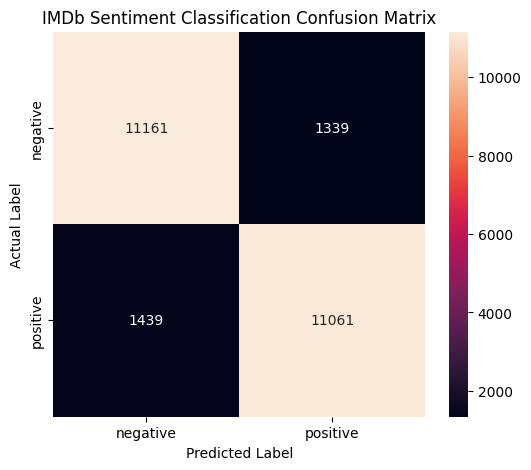

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix_result,
    annot=True,
    fmt="d",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("IMDb Sentiment Classification Confusion Matrix")
plt.show()

## 10. Hyperparameter Tuning with Cross-Validation

The Linear SVM regularization parameter `C` controls the trade-off between achieving a wider decision margin and minimizing classification errors on the training data.

To select an appropriate value for `C`, cross-validation is performed using only the training dataset. The held-out IMDb test dataset is not used during hyperparameter selection.

The TF-IDF vectorizer and Linear SVM classifier are kept together inside a single Pipeline during cross-validation. This ensures that TF-IDF is fitted independently within each cross-validation fold and prevents information from one fold from influencing another.

Five-fold cross-validation is used to evaluate a small predefined set of `C` values.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

cv_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            random_state=42
        )
    )
])

In [23]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=cv_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    train_data["review"],
    train_y
)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95, min_df=2,
                                                        ngram_range=(1, 2),
                                                        stop_words='english',
                                                        sublinear_tf=True)),
                                       ('classifier',
                                        LinearSVC(random_state=42))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1.0, 10.0]},
             scoring='f1', verbose=1)

In [24]:
print("Best C:", grid_search.best_params_["classifier__C"])
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

Best C: 1.0
Best cross-validation F1-score: 0.9001


## 11. Final Model Performance

The Linear SVM model was evaluated on the unseen IMDb test dataset containing 25,000 reviews.

Five-fold cross-validation on the training dataset selected `C = 1.0` as the best regularization parameter. The final performance reported below is based on the previously completed evaluation on the held-out test dataset.

### Final Test Performance

| Metric | Score |
|---|---:|
| Accuracy | 88.89% |
| Precision | 89.20% |
| Recall | 88.49% |
| F1-score | 88.84% |

The model achieved an F1-score of 88.84% on the IMDb test dataset, demonstrating strong performance in distinguishing positive and negative movie reviews using TF-IDF features and a Linear SVM classifier.

## 12. Final Deployment Pipeline

For deployment, the TF-IDF vectorizer and Linear SVM classifier are combined into a single scikit-learn Pipeline.

The pipeline uses the final configuration selected during model development:

- TF-IDF with unigrams and bigrams
- English stop-word removal
- Minimum document frequency of 2
- Maximum document frequency of 0.95
- Sublinear term frequency
- Linear SVM with `C = 1.0`

The complete pipeline accepts raw movie review text and automatically performs TF-IDF transformation before generating the sentiment prediction.

In [26]:
final_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            random_state=42
        )
    )
])

In [27]:
final_pipeline.fit(
    train_data["review"],
    train_y
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 stop_words='english', sublinear_tf=True)),
                ('classifier', LinearSVC(random_state=42))])

## 12. Save the Final Model

The trained TF-IDF and Linear SVM pipeline is saved as a single model artifact using Joblib.

Saving the complete pipeline ensures that the TF-IDF vectorization and sentiment classification steps are preserved together. The saved artifact can therefore accept raw movie review text directly when loaded in the Streamlit application.

The model will be stored in the project directory for use during deployment.

In [28]:
import joblib
model_path = "IMDB_Sentiment_Model.pkl"

joblib.dump(
    final_pipeline,
    model_path
)

print("Model saved successfully.")
print("Saved model path:", model_path)

Model saved successfully.
Saved model path: IMDB_Sentiment_Model.pkl


In [30]:
from google.colab import files
files.download("IMDB_Sentiment_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Model Reload Verification

The saved model artifact is reloaded from disk to verify that the complete TF-IDF and Linear SVM pipeline was saved correctly.

A sample movie review is then passed directly to the reloaded pipeline. This confirms that the deployment artifact can accept raw review text and generate a sentiment prediction without requiring any separate preprocessing or vectorization steps.

In [29]:
loaded_pipeline = joblib.load(model_path)

sample_review = """
This movie was absolutely fantastic. The story was engaging,
the performances were excellent, and I thoroughly enjoyed watching it.
"""

sample_prediction = loaded_pipeline.predict(
    [sample_review]
)[0]

if sample_prediction == 1:
    sample_sentiment = "positive"
else:
    sample_sentiment = "negative"

print("Predicted sentiment:", sample_sentiment)

Predicted sentiment: positive


## 14. Conclusion

This project developed a classical machine learning approach for binary sentiment classification of IMDb movie reviews.

The review text was transformed into numerical features using TF-IDF, with unigrams and bigrams used to capture individual words and short phrases. A Linear Support Vector Machine was then trained to classify reviews as positive or negative.

Five-fold cross-validation was used on the training data to select the Linear SVM regularization parameter, with `C = 1.0` selected as the best value.

The final model achieved the following performance on the held-out IMDb test dataset:

- Accuracy: 88.89%
- Precision: 89.20%
- Recall: 88.49%
- F1-score: 88.84%

The complete TF-IDF and Linear SVM workflow was saved as a single scikit-learn Pipeline, making the model suitable for integration into a Streamlit application.

The Streamlit application will allow users to enter a movie review and receive a predicted sentiment of either positive or negative.